Ea = (111.2 +/- 5.6) kJ/mol


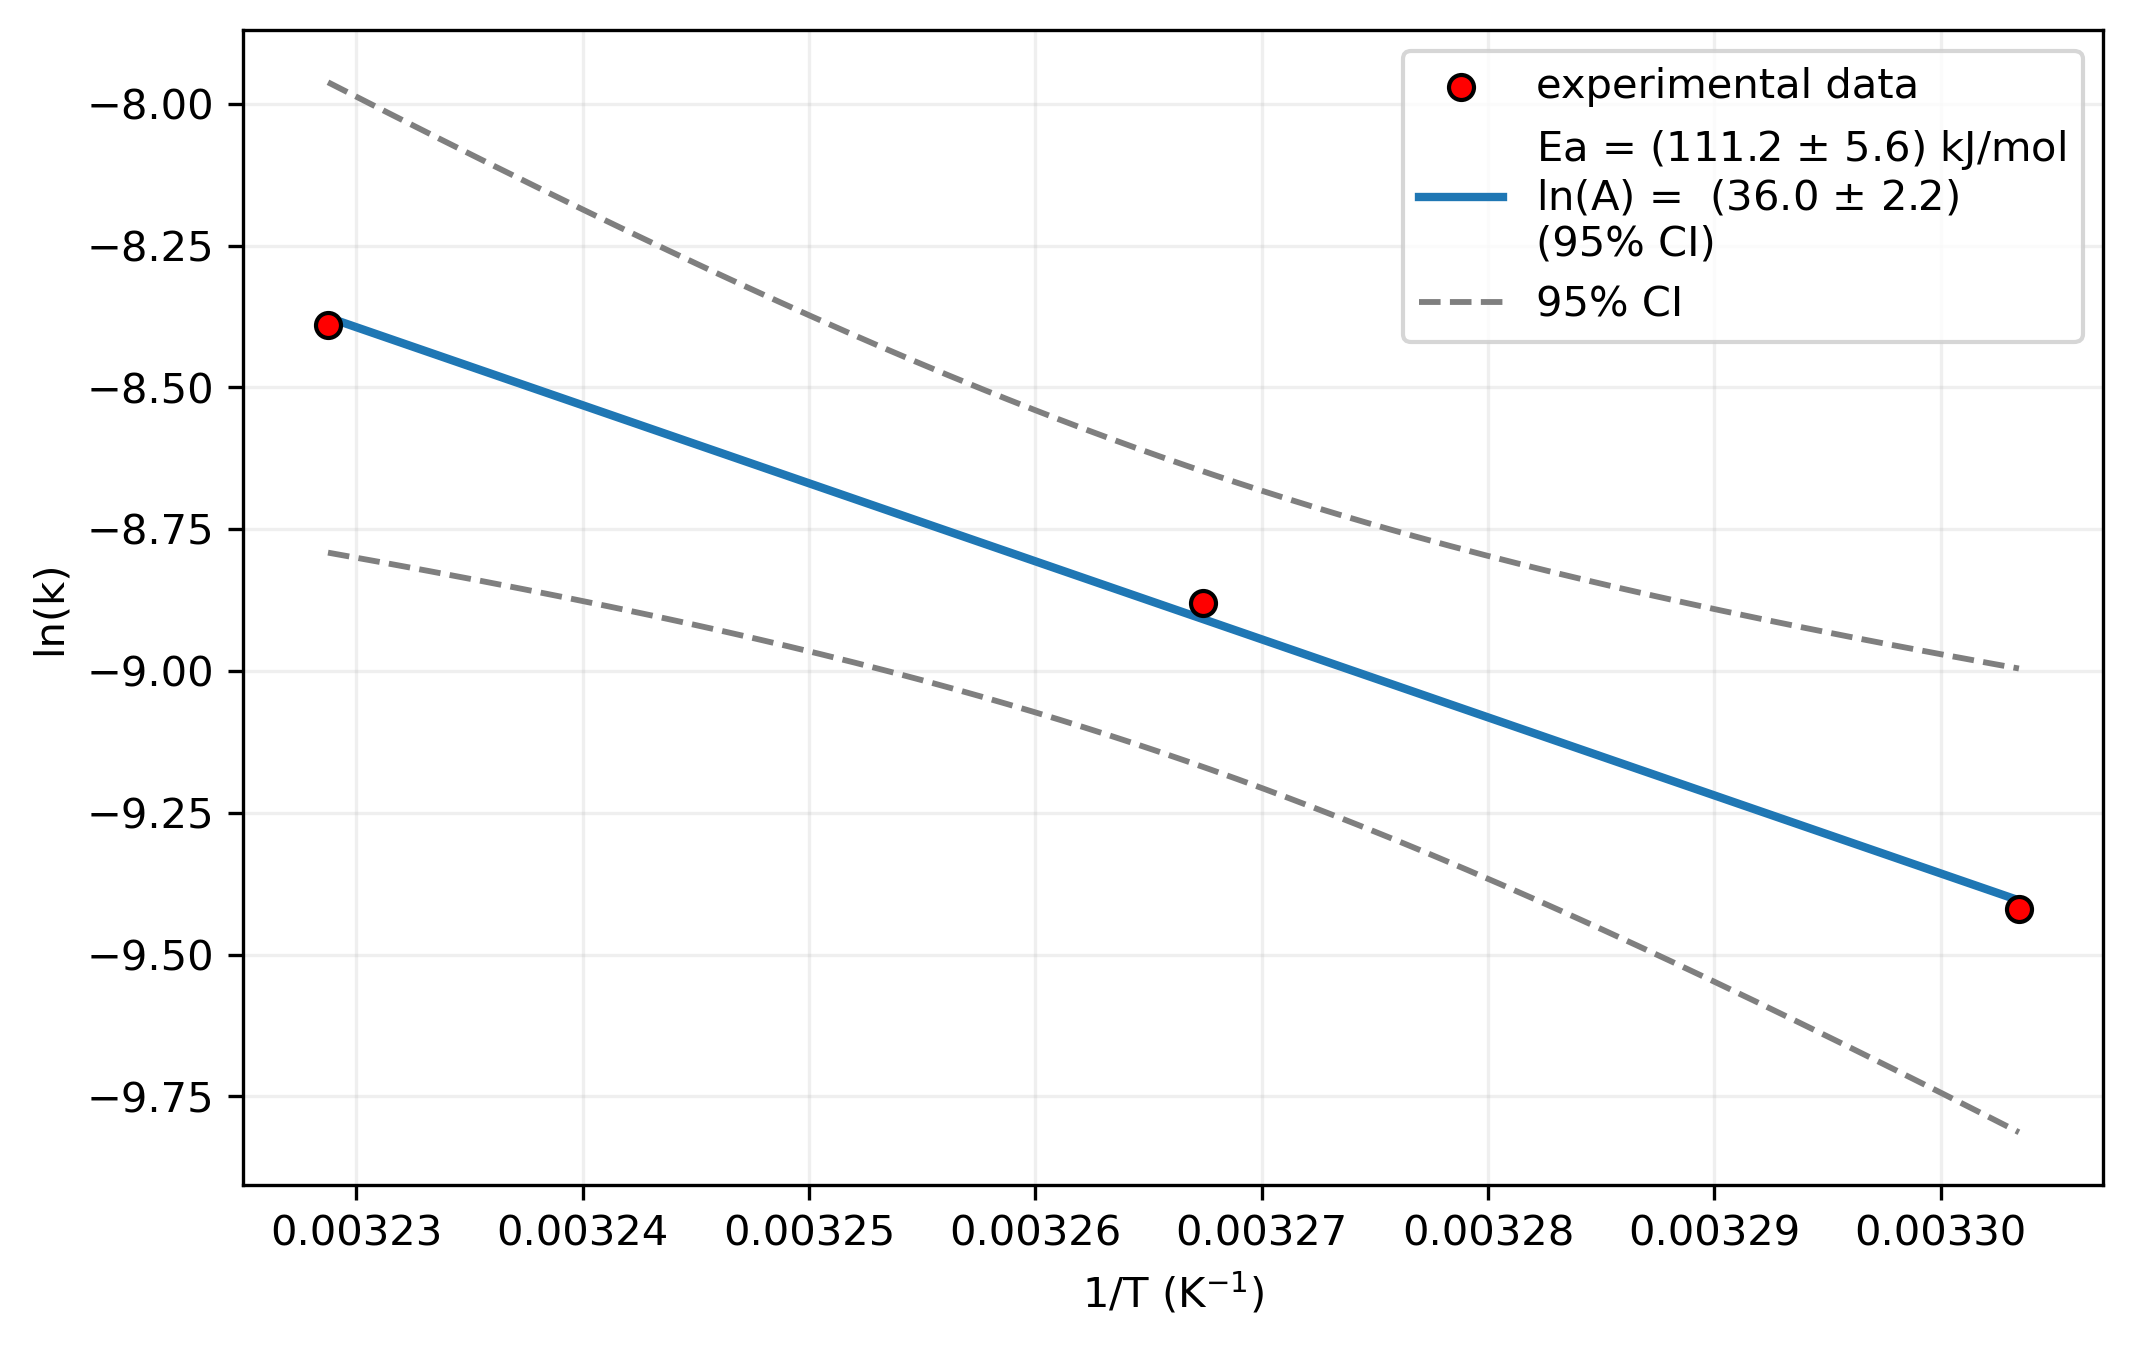

In [10]:
from sklearn.linear_model import LinearRegression
import numpy as np
from scipy.stats import t
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd
from scipy.constants import R

df = pd.read_csv('ea_dat.tsv', sep='\t')
df['Temperature'] += 273.15
df['k'] = df['Rate'] / (df['[HCl]']**0.954 * df['[Acetone]']**1.026)
df['ln(k)'] = df['k'].apply(lambda x: np.log(x))
k = df['k'].to_numpy()
T = df['Temperature'].to_numpy()

X_arr = (1 / T).reshape(1, -1)
y_arr = np.log(k)

arr_lr = LinearRegression()
X_arr = (1 / T).reshape(-1, 1)
arr_lr.fit(X_arr, y_arr)

slope = arr_lr.coef_[0]
intercept = arr_lr.intercept_
X_design = np.column_stack((X_arr.ravel(), np.ones_like(y_arr)))
resid = y_arr - arr_lr.predict(X_arr)
sigma2 = np.sum(resid**2) / (len(y_arr) - 2)
cov_matrix = sigma2 * np.linalg.inv(X_design.T @ X_design)

slope_err = np.sqrt(cov_matrix[0, 0])
intercept_err = np.sqrt(cov_matrix[1, 1])

# Regression line in ln(k) vs 1/T space
x = X_arr.ravel()
x_fit = np.linspace(x.min(), x.max(), 200)
# arr_lr.coef_[0] = -111225.40442535149/R
y_fit = arr_lr.predict(x_fit.reshape(-1, 1))


# 95% CI for mean regression line
n = len(x)
dof = n - 2
resid = y_arr - arr_lr.predict(X_arr)
s_err = np.sqrt(np.sum(resid**2) / dof)
x_mean = np.mean(x)
Sxx = np.sum((x - x_mean) ** 2)
t_crit = t.ppf(0.975, dof)

ci = t_crit * s_err * np.sqrt(1 / n + (x_fit - x_mean) ** 2 / Sxx)
y_upper = y_fit + ci
y_lower = y_fit - ci

#
Ea = 111225.40442535149/1000 # from separate document
Ea_error = slope_err*R / 1000
print(f'Ea = ({Ea:.1f} +/- {Ea_error:.1f}) kJ/mol')

# Plot
plt.figure(figsize=(8, 5), dpi=300)
plt.scatter(x, y_arr, color="red", label="experimental data", zorder=3, edgecolor='black')
plt.plot(x_fit, y_fit, color="tab:blue", lw=2, 
         label=f"Ea = ({Ea:.1f} $\pm$ {Ea_error:.1f}) kJ/mol\nln(A) =  ({intercept:.1f} $\pm$ {intercept_err:.1f})\n(95% CI)")
plt.plot(x_fit, y_upper, "--", color="tab:grey", lw=1.4, label="95% CI")
plt.plot(x_fit, y_lower, "--", color="tab:grey", lw=1.4)
plt.xlabel("1/T (K$^{-1}$)")
plt.ylabel("ln(k)")
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda val, _: f"{val:.5f}"))
plt.grid(alpha=0.2)
plt.legend();
plt.savefig('activationenergy.pdf')

Ea = (111.2 +/- 5.6) kJ/mol


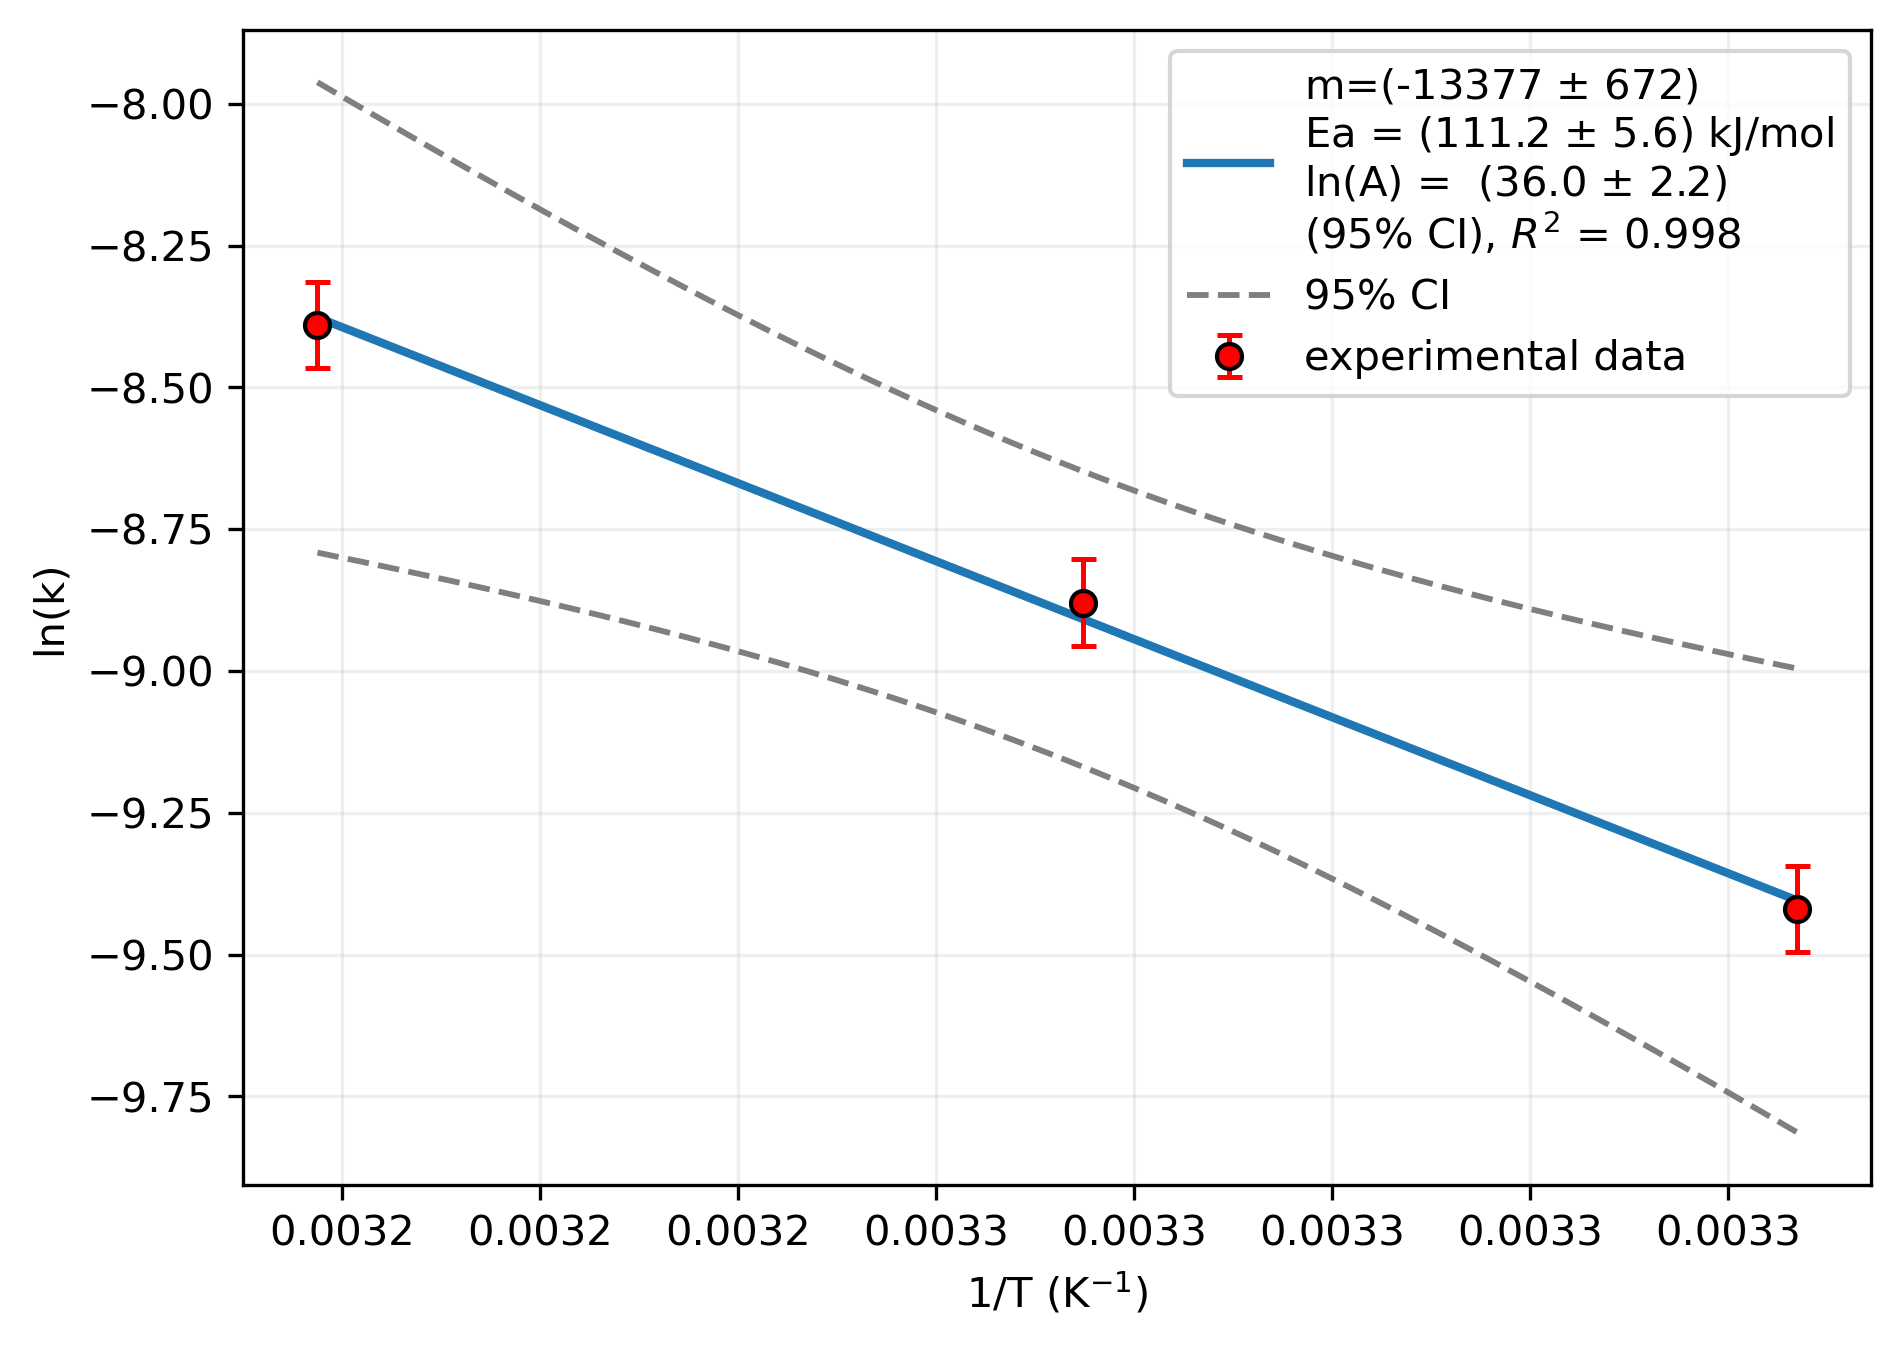

In [11]:
from sklearn.metrics import r2_score


# --- error propagation for ln(k) ---
alpha, beta, gamma = 0.954, 1.026, -0.134  # exponents (beta=0 since no I2 in k)
t_value = 3.182446305284263
d_alpha, d_beta, d_gamma = 0.063/t_value, 0.068/t_value, 0.067/t_value # exponent errors — fill in if known

delta_lnk = np.sqrt(
    (df['δ Rate']    / df['Rate'])      **2 +
    np.log(df['[HCl]'])     **2 * d_alpha**2 +
    np.log(df['[Acetone]']) **2 * d_gamma**2
).to_numpy()

X_arr = (1 / T).reshape(1, -1)
y_arr = np.log(k)

arr_lr = LinearRegression()
X_arr = (1 / T).reshape(-1, 1)
arr_lr.fit(X_arr, y_arr)

slope = arr_lr.coef_[0]
intercept = arr_lr.intercept_
X_design = np.column_stack((X_arr.ravel(), np.ones_like(y_arr)))
resid = y_arr - arr_lr.predict(X_arr)
sigma2 = np.sum(resid**2) / (len(y_arr) - 2)
cov_matrix = sigma2 * np.linalg.inv(X_design.T @ X_design)

slope_err = np.sqrt(cov_matrix[0, 0])
intercept_err = np.sqrt(cov_matrix[1, 1])

# Regression line in ln(k) vs 1/T space
x = X_arr.ravel()
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = arr_lr.predict(x_fit.reshape(-1, 1))

# 95% CI for mean regression line
n = len(x)
dof = n - 2
resid = y_arr - arr_lr.predict(X_arr)
s_err = np.sqrt(np.sum(resid**2) / dof)
x_mean = np.mean(x)
Sxx = np.sum((x - x_mean) ** 2)
t_crit = t.ppf(0.975, dof)

ci = t_crit * s_err * np.sqrt(1 / n + (x_fit - x_mean) ** 2 / Sxx)
y_upper = y_fit + ci
y_lower = y_fit - ci
r2 = r2_score(y_arr, arr_lr.predict(X_arr))


Ea = 111225/1000
Ea_error = slope_err * R / 1000
print(f'Ea = ({Ea:.1f} +/- {Ea_error:.1f}) kJ/mol')

# Plot
plt.figure(figsize=(7, 5), dpi=300)
plt.errorbar(x, y_arr, yerr=delta_lnk,
             fmt='o', color='red', ecolor='red', elinewidth=1.2,
             capsize=3, capthick=1.2,
             label='experimental data', zorder=3,
             markeredgecolor='black')
plt.plot(x_fit, y_fit, color="tab:blue", lw=2,
         label=f"m=({1000*Ea/R/-1:.0f} $\pm$ {slope_err:.0f})\nEa = ({Ea:.1f} $\pm$ {Ea_error:.1f}) kJ/mol\n"
               f"ln(A) =  ({intercept:.1f} $\pm$ {intercept_err:.1f})\n"
               f"(95% CI), $R^2$ = {r2:.3f}")
plt.plot(x_fit, y_upper, "--", color="tab:grey", lw=1.4, label="95% CI")
plt.plot(x_fit, y_lower, "--", color="tab:grey", lw=1.4)
plt.xlabel("1/T (K$^{-1}$)")
plt.ylabel("ln(k)")
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda val, _: f"{val:.4f}"))
plt.grid(alpha=0.2)
plt.legend()
plt.savefig('activationenergy.pdf')

In [12]:
Ea = 111225
slope = Ea/R
slope

13377.292689627206